# A logical progression through classic machine-learning models

The examples progress from simple decision boundaries to class imbalance, generalization, ensembles, and regression.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, mean_absolute_error, r2_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBRegressor

In [15]:
import seaborn as sns

penguins = sns.load_dataset("penguins").dropna()

features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

penguins[features].head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


## Regression, correlation, and PCA

The correlation matrix we saw earlier is doing more work than it may first appear.

Linear regression uses covariance to determine how strongly one variable should change as another changes.

PCA also starts from the covariance matrix, but asks a different question:

> In which directions does the dataset vary the most?

Regression chooses a direction specifically to predict `y` from `X`.
PCA ignores which variable is the target and instead looks for directions that summarize the whole dataset.

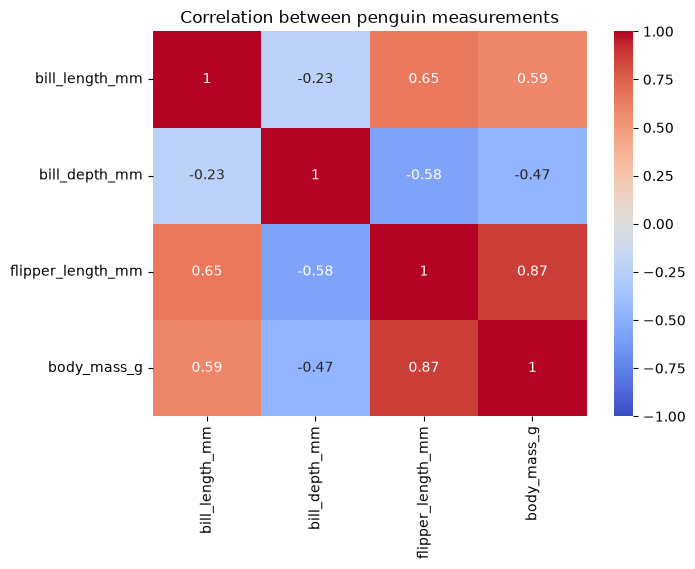

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    penguins[features].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Correlation between penguin measurements")
plt.show()

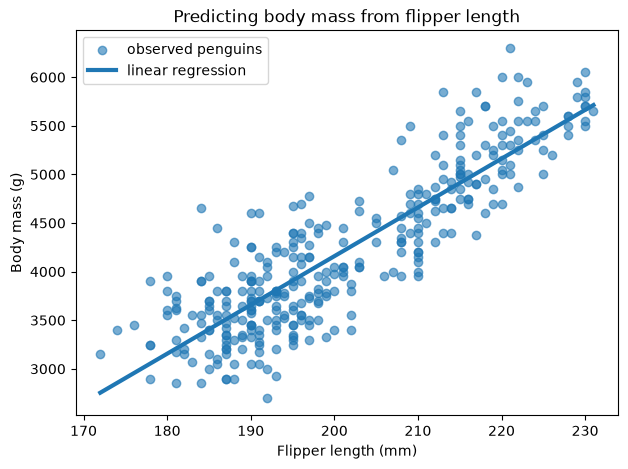

MAE: 312 g
R²:  0.762


In [17]:
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


X = penguins[["flipper_length_mm"]]
y = penguins["body_mass_g"]

model = LinearRegression()
model.fit(X, y)

predicted_mass = model.predict(X)

plt.figure(figsize=(7, 5))

plt.scatter(
    X["flipper_length_mm"],
    y,
    alpha=0.6,
    label="observed penguins",
)

order = X["flipper_length_mm"].argsort()

plt.plot(
    X["flipper_length_mm"].iloc[order],
    predicted_mass[order],
    linewidth=3,
    label="linear regression",
)

plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Predicting body mass from flipper length")
plt.legend()
plt.show()

print(f"MAE: {mean_absolute_error(y, predicted_mass):.0f} g")
print(f"R²:  {r2_score(y, predicted_mass):.3f}")

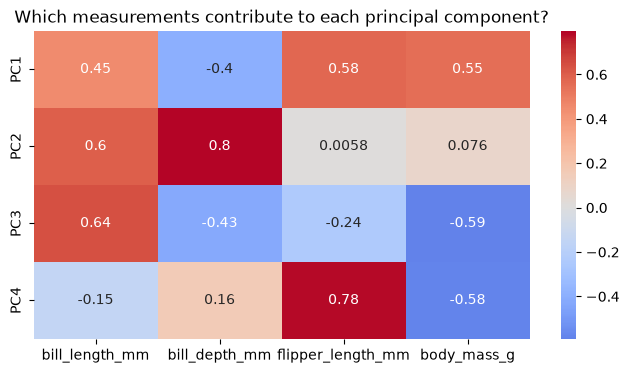

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


penguins = sns.load_dataset("penguins").dropna()

features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

X = penguins[features]

# PCA is sensitive to scale, so standardize the measurements first.
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

loadings = pca.components_

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0,
    xticklabels=features,
    yticklabels=[f"PC{i + 1}" for i in range(len(features))],
    ax=ax,
)

ax.set_title("Which measurements contribute to each principal component?")
plt.show()

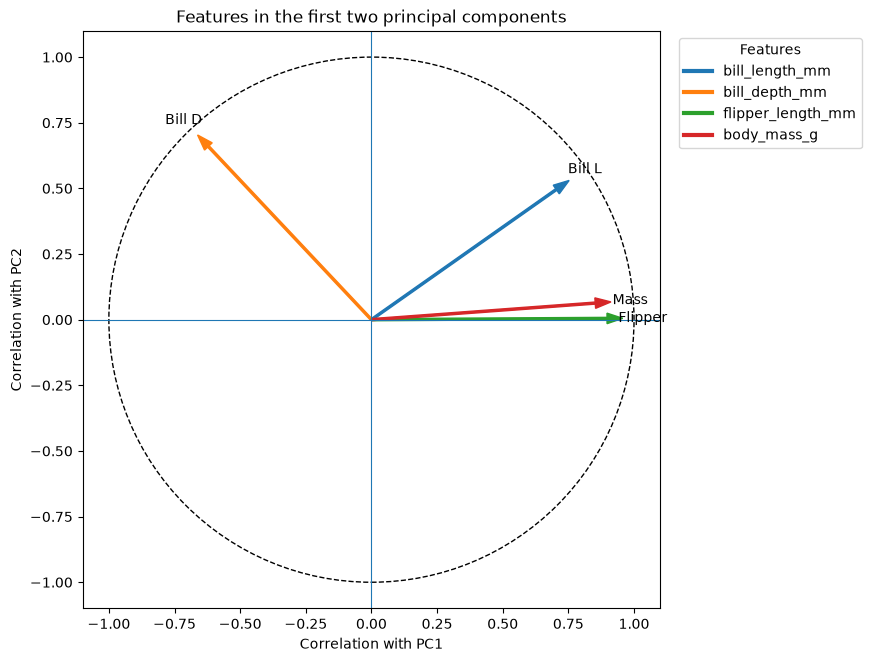

In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Correlation of each original feature with PC1 and PC2
feature_correlations = (
    pca.components_[:2].T
    * (pca.explained_variance_[:2] ** 0.5)
)

short_names = {
    "bill_length_mm": "Bill L",
    "bill_depth_mm": "Bill D",
    "flipper_length_mm": "Flipper",
    "body_mass_g": "Mass",
}

fig, ax = plt.subplots(figsize=(8, 7))

colors = plt.cm.tab10(range(len(features)))

legend_handles = []

for feature, (pc1, pc2), color in zip(
    features,
    feature_correlations,
    colors,
):
    ax.arrow(
        0,
        0,
        pc1,
        pc2,
        color=color,
        width=0.008,
        head_width=0.04,
        length_includes_head=True,
    )

    # Short label next to the arrow
    ax.text(
        pc1 * 1.08,
        pc2 * 1.08,
        short_names[feature],
        ha="center",
        va="center",
    )

    # Full feature name in the legend
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=3,
            label=feature,
        )
    )

# Unit circle
circle = plt.Circle(
    (0, 0),
    1,
    fill=False,
    linestyle="--",
    linewidth=1,
)
ax.add_patch(circle)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")

ax.set_xlabel("Correlation with PC1")
ax.set_ylabel("Correlation with PC2")
ax.set_title("Features in the first two principal components")

ax.legend(
    handles=legend_handles,
    title="Features",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

plt.tight_layout()
plt.show()

# Classification

## Shared visual helpers
These functions keep the dataset, decision-boundary, and regression plots visually consistent.

In [2]:
FEATURES_2D = ["x1", "x2"]


def plot_points(data, ax, title):
    for label, colour in [(0, "tab:blue"), (1, "tab:orange")]:
        rows = data[data["class"] == label]
        ax.scatter(rows["x1"], rows["x2"], c=colour, label=f"class {label}", alpha=0.7, edgecolors="white")
    ax.set(title=title, xlabel="x1", ylabel="x2")
    ax.legend()
    ax.grid(alpha=0.2)


def display_points(data, title, test=None):
    datasets = [("Observed data", data)] if test is None else [("Training data", data), ("Test data", test)]
    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharex=True, sharey=True, squeeze=False)
    for ax, (split_title, split_data) in zip(axes[0], datasets):
        plot_points(split_data, ax, split_title)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def display_classifications(model, train, title, test=None):
    datasets = [("Observed data", train)] if test is None else [("Training data", train), ("Test data", test)]
    combined = pd.concat([data for _, data in datasets])
    x1 = np.linspace(combined["x1"].min() - 0.5, combined["x1"].max() + 0.5, 250)
    x2 = np.linspace(combined["x2"].min() - 0.5, combined["x2"].max() + 0.5, 250)
    grid_x1, grid_x2 = np.meshgrid(x1, x2)
    grid = pd.DataFrame({"x1": grid_x1.ravel(), "x2": grid_x2.ravel()})
    probabilities = model.predict_proba(grid)[:, 1].reshape(grid_x1.shape)

    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharex=True, sharey=True, squeeze=False)
    for ax, (split_title, data) in zip(axes[0], datasets):
        ax.contourf(grid_x1, grid_x2, probabilities, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
        ax.contour(grid_x1, grid_x2, probabilities, levels=[0.5], colors="black", linewidths=2)
        plot_points(data, ax, split_title)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def display_regression_measurements(train, test):
    combined = pd.concat([train, test])
    vmin, vmax = combined["target"].min(), combined["target"].max()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True, constrained_layout=True)
    for ax, (title, data) in zip(axes, [("Training measurements", train), ("Test measurements", test)]):
        points = ax.scatter(data["x1"], data["x2"], c=data["target"], cmap="hot", vmin=vmin, vmax=vmax, s=12)
        ax.set(title=title, xlabel="x1", ylabel="x2")
    fig.colorbar(points, ax=axes, label="target", shrink=0.85)
    plt.show()


def display_regression_results(surface, predictions):
    x1 = surface["x1"].unique()
    x2 = surface["x2"].unique()
    grid_shape = (len(x2), len(x1))
    extent = [x1.min(), x1.max(), x2.min(), x2.max()]
    truth = surface["target"].to_numpy()
    vmin, vmax = truth.min(), truth.max()

    surfaces = [("True piecewise function", truth), *predictions.items()]
    fig, axes = plt.subplots(1, len(surfaces), figsize=(4.5 * len(surfaces), 4), constrained_layout=True)
    for ax, (title, values) in zip(axes, surfaces):
        image = ax.imshow(values.reshape(grid_shape), origin="lower", extent=extent, cmap="hot", vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
        ax.set(title=title, xlabel="x1", ylabel="x2")
    fig.colorbar(image, ax=axes, label="target", shrink=0.85)
    plt.show()

    absolute_errors = {name: np.abs(values - truth) for name, values in predictions.items()}
    error_max = max(errors.max() for errors in absolute_errors.values())
    fig, axes = plt.subplots(1, len(absolute_errors), figsize=(4.5 * len(absolute_errors), 4), constrained_layout=True)
    for ax, (name, errors) in zip(axes, absolute_errors.items()):
        image = ax.imshow(errors.reshape(grid_shape), origin="lower", extent=extent, cmap="Blues", vmin=0, vmax=error_max, aspect="equal", interpolation="nearest")
        ax.set(title=f"{name}: absolute error", xlabel="x1", ylabel="x2")
    fig.colorbar(image, ax=axes, label="absolute error |prediction - truth|", shrink=0.85)
    plt.show()

## Step 1: one straight boundary
Logistic regression is sufficient when one straight line separates the classes.

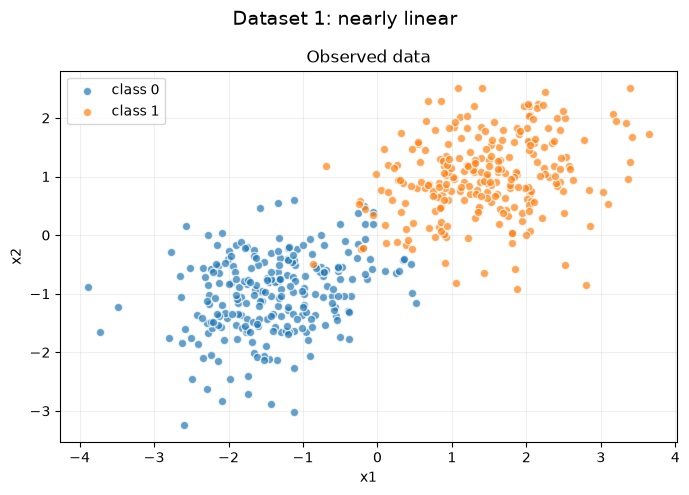

In [4]:
linear_data = pd.read_csv("data1_linear.csv")
display_points(linear_data, "Dataset 1: nearly linear")

In [5]:
# Exercise: Fit your first model.
# Create a LogisticRegression model, fit it using x1 and x2 to predict class,
# calculate its accuracy, and display its decision boundary.

accuracy on observed data: 0.982


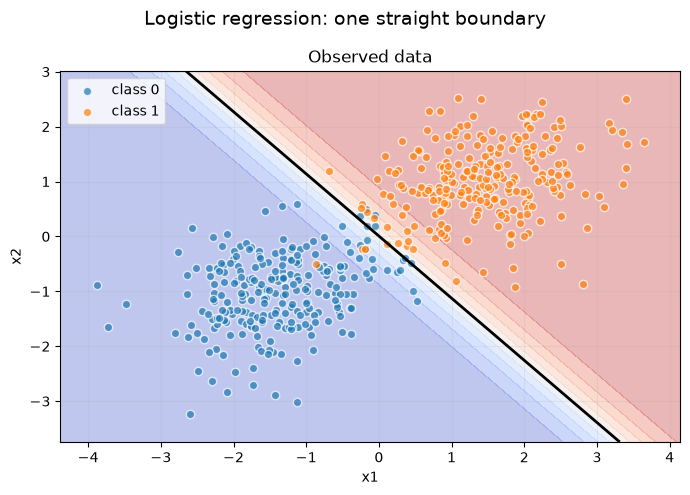

In [6]:
# Solution
linear_model = LogisticRegression()
linear_model.fit(linear_data[FEATURES_2D], linear_data["class"])
linear_predictions = linear_model.predict(linear_data[FEATURES_2D])
print(f"accuracy on observed data: {accuracy_score(linear_data['class'], linear_predictions):.3f}")
display_classifications(linear_model, linear_data, "Logistic regression: one straight boundary")

## Step 2: accuracy can reward a useless model
High accuracy can hide poor minority-class performance when classes are imbalanced.

training class proportions:


class
0    0.95
1    0.05
Name: proportion, dtype: float64

test class proportions:


class
0    0.5
1    0.5
Name: proportion, dtype: float64

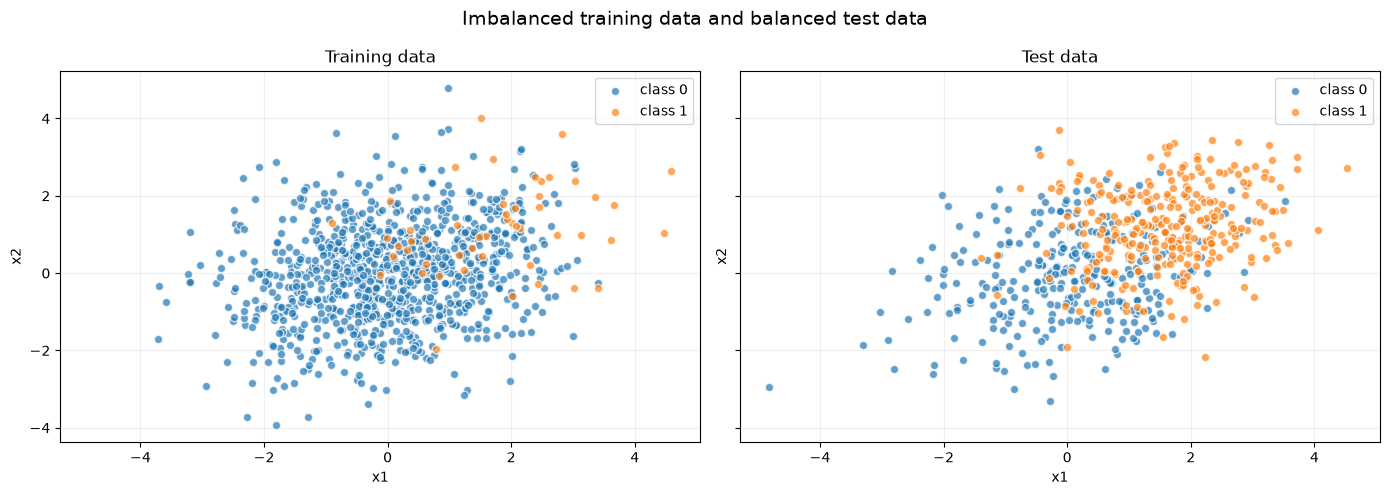

In [7]:
imbalanced_train = pd.read_csv("data5_imbalanced_train.csv")
imbalanced_test = pd.read_csv("data5_imbalanced_test.csv")
print("training class proportions:")
display(imbalanced_train["class"].value_counts(normalize=True).sort_index().rename("proportion"))
print("test class proportions:")
display(imbalanced_test["class"].value_counts(normalize=True).sort_index().rename("proportion"))
display_points(imbalanced_train, "Imbalanced training data and balanced test data", imbalanced_test)

In [8]:
# Exercise: Evaluate models when one class is rare.
# Fit the three models below, then compare accuracy, balanced accuracy, positive
# recall, confusion matrices, and decision boundaries on the train and test data.

In [9]:
# Solution
imbalance_models = {
    "always no": DummyClassifier(strategy="constant", constant=0),
    "logistic regression": LogisticRegression(),
    "class-balanced logistic": LogisticRegression(class_weight="balanced"),
}

rows = []
for name, model in imbalance_models.items():
    model.fit(imbalanced_train[FEATURES_2D], imbalanced_train["class"])
    for split_name, data in [("train", imbalanced_train), ("test", imbalanced_test)]:
        predictions = model.predict(data[FEATURES_2D])
        rows.append({
            "model": name,
            "split": split_name,
            "accuracy": accuracy_score(data["class"], predictions),
            "balanced accuracy": balanced_accuracy_score(data["class"], predictions),
            "positive recall": recall_score(data["class"], predictions, zero_division=0),
        })
results = pd.DataFrame(rows)
results.set_index(["model", "split"]).round(3)

accuracy  balanced accuracy  positive recall
model                   split                                              
always no               train     0.950              0.500            0.000
                        test      0.500              0.500            0.000
logistic regression     train     0.955              0.569            0.140
                        test      0.538              0.538            0.080
class-balanced logistic train     0.782              0.753            0.720
                        test      0.807              0.807            0.817

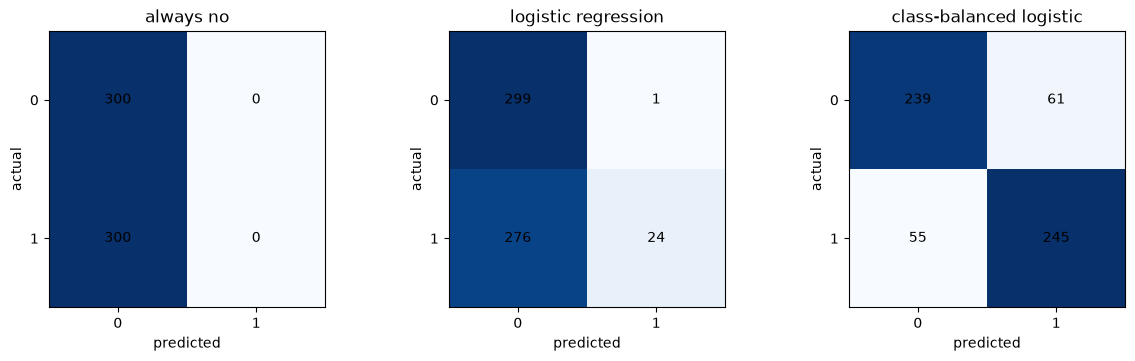

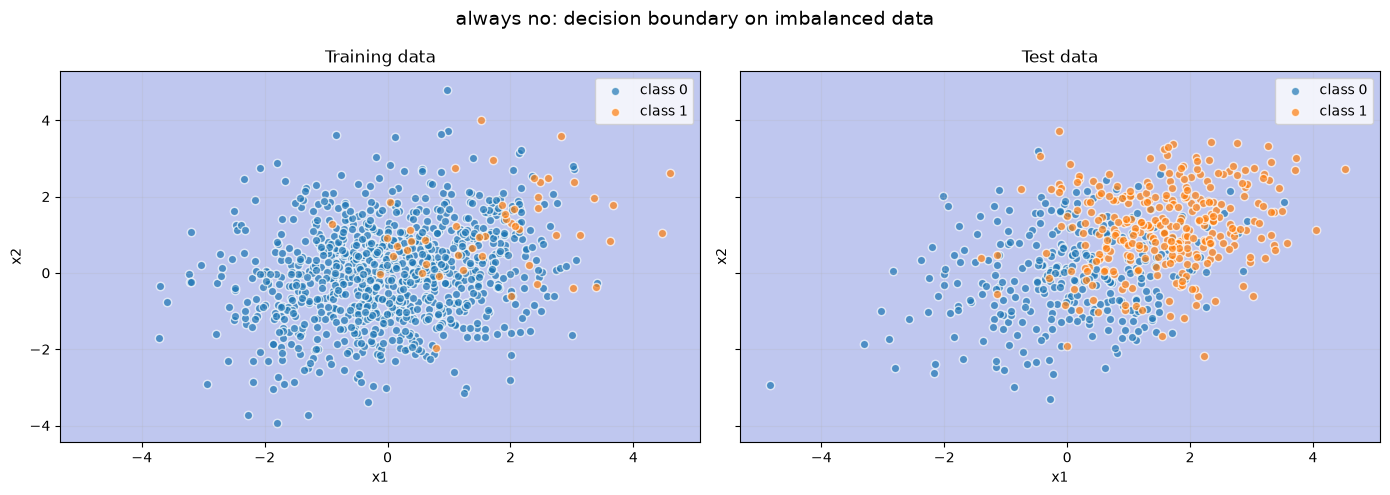

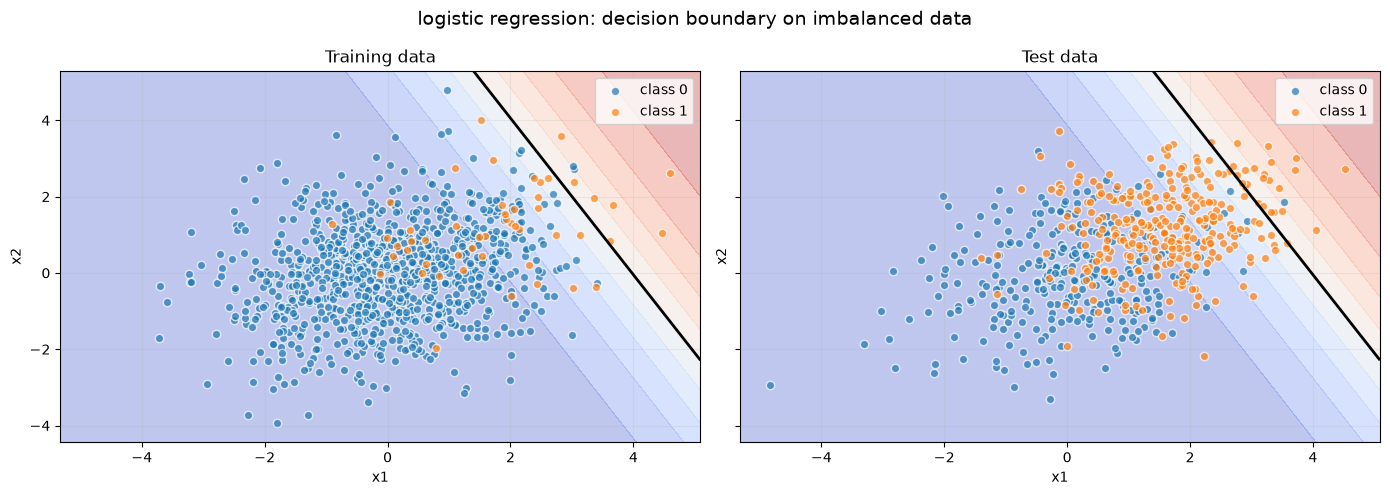

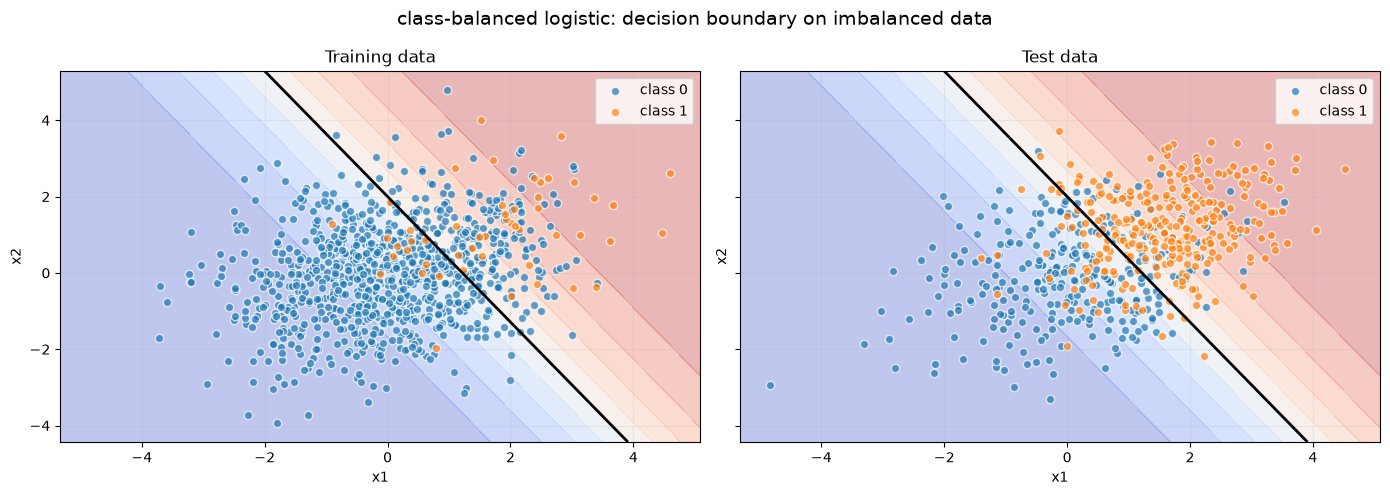

In [9]:
def plot_test_confusions(models):
    _, axes = plt.subplots(1, len(models), figsize=(12, 3.5), constrained_layout=True)
    for ax, (name, model) in zip(axes, models.items()):
        cm = confusion_matrix(imbalanced_test["class"], model.predict(imbalanced_test[FEATURES_2D]))
        ax.imshow(cm, cmap="Blues")
        ax.set(title=name, xlabel="predicted", ylabel="actual", xticks=[0, 1], yticks=[0, 1])
        for row in range(2):
            for column in range(2):
                ax.text(column, row, cm[row, column], ha="center", va="center")
    plt.show()


plot_test_confusions(imbalance_models)
for name, model in imbalance_models.items():
    display_classifications(
        model, imbalanced_train,
        f"{name}: decision boundary on imbalanced data",
        test=imbalanced_test,
    )

## Step 3: one line is not enough
XOR requires several cuts because opposite corners share a class.

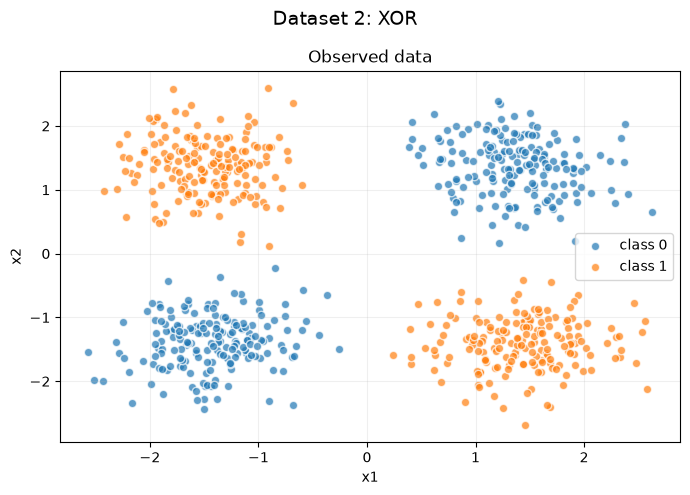

In [10]:
xor_data = pd.read_csv("data2_nonlinear.csv")
display_points(xor_data, "Dataset 2: XOR")

In [11]:
# Exercise: Test the limits of a linear decision boundary.
# Fit logistic regression to the XOR data, calculate its accuracy, and display
# its decision boundary. What pattern can the model not represent?

accuracy on observed data: 0.497


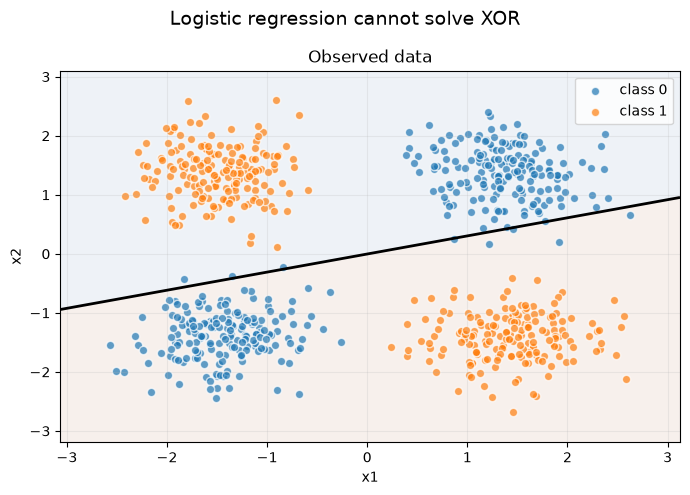

In [13]:
# Solution
xor_logistic = LogisticRegression()
xor_logistic.fit(xor_data[FEATURES_2D], xor_data["class"])
xor_predictions = xor_logistic.predict(xor_data[FEATURES_2D])
print(f"accuracy on observed data: {accuracy_score(xor_data['class'], xor_predictions):.3f}")
display_classifications(xor_logistic, xor_data, "Logistic regression cannot solve XOR")

In [14]:
# Exercise: Fit a model that can represent XOR.
# Create a decision tree with fit it to the same data, calculate
# its accuracy, and display its decision boundary.

accuracy on observed data: 1.000


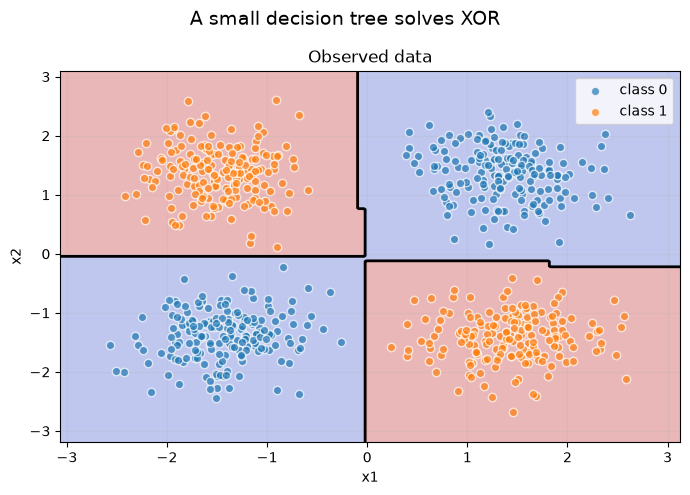

In [15]:
# Solution
xor_tree = DecisionTreeClassifier(random_state=23)
xor_tree.fit(xor_data[FEATURES_2D], xor_data["class"])
xor_tree_predictions = xor_tree.predict(xor_data[FEATURES_2D])
print(f"accuracy on observed data: {accuracy_score(xor_data['class'], xor_tree_predictions):.3f}")
display_classifications(xor_tree, xor_data, "A small decision tree solves XOR")

## Step 4: training data versus unseen data
A held-out test set distinguishes memorization from generalization.

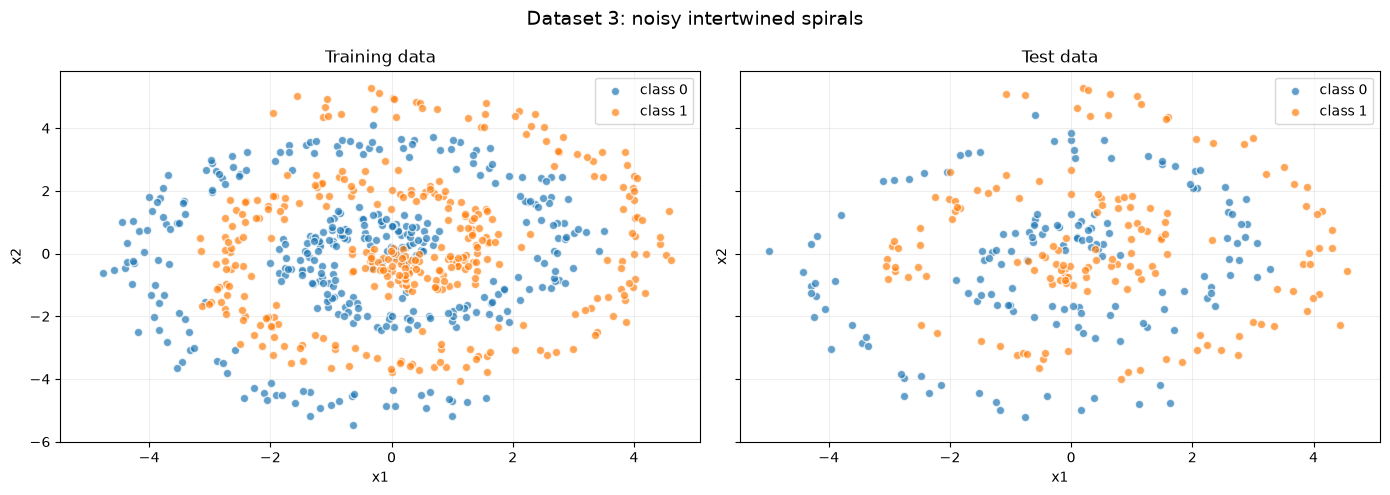

In [16]:
def split_data(data, test_size=0.3):
    return train_test_split(
        data, test_size=test_size, stratify=data["class"], random_state=42
    )


spiral_train, spiral_test = split_data(pd.read_csv("data3_spiral.csv"))
display_points(spiral_train, "Dataset 3: noisy intertwined spirals", spiral_test)

training accuracy: 1.000
accuracy on unseen test data: 0.917


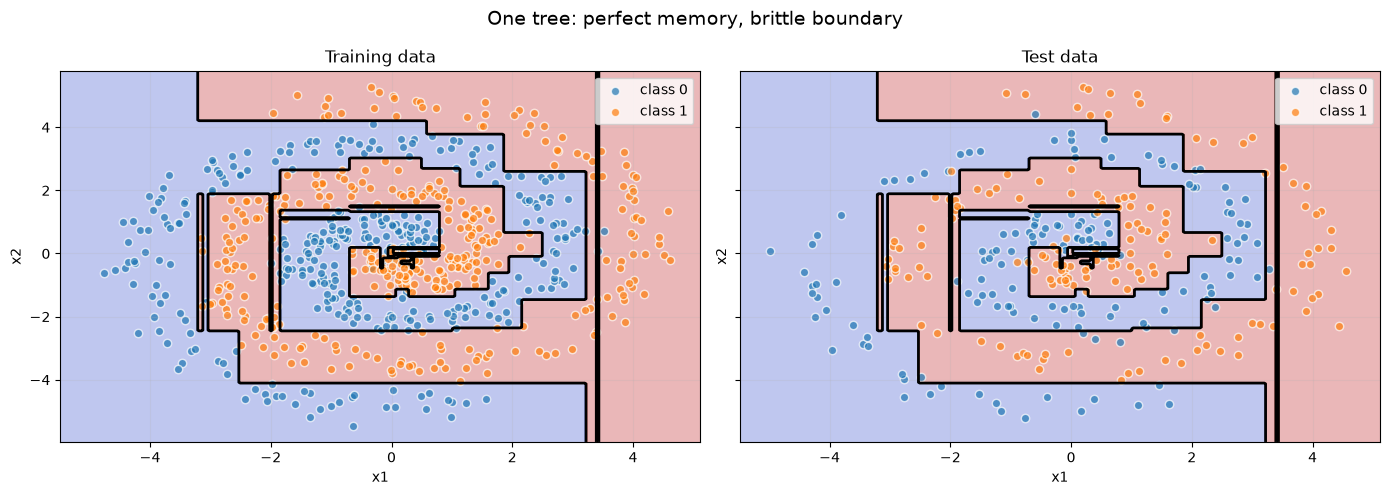

In [21]:
# Solution
spiral_tree = DecisionTreeClassifier(random_state=42)
spiral_tree.fit(spiral_train[FEATURES_2D], spiral_train["class"])
tree_train_predictions = spiral_tree.predict(spiral_train[FEATURES_2D])
tree_test_predictions = spiral_tree.predict(spiral_test[FEATURES_2D])
print(f"training accuracy: {accuracy_score(spiral_train['class'], tree_train_predictions):.3f}")
print(f"accuracy on unseen test data: {accuracy_score(spiral_test['class'], tree_test_predictions):.3f}")
display_classifications(spiral_tree, spiral_train, "One tree: perfect memory, brittle boundary", test=spiral_test)

In [22]:
# Exercise: Reduce the instability of one tree.
# Fit a random forest, compare its training and test accuracy with the tree,
# and display its decision boundary.

#try and use n_estimators and max_depth parameter and other options

In [23]:
help(RandomForestClassifier.__init__)

Help on function __init__ in module sklearn.ensemble._forest:

__init__(self, n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
    Initialize self.  See help(type(self)) for accurate signature.



training accuracy: 1.000
accuracy on unseen test data: 0.950


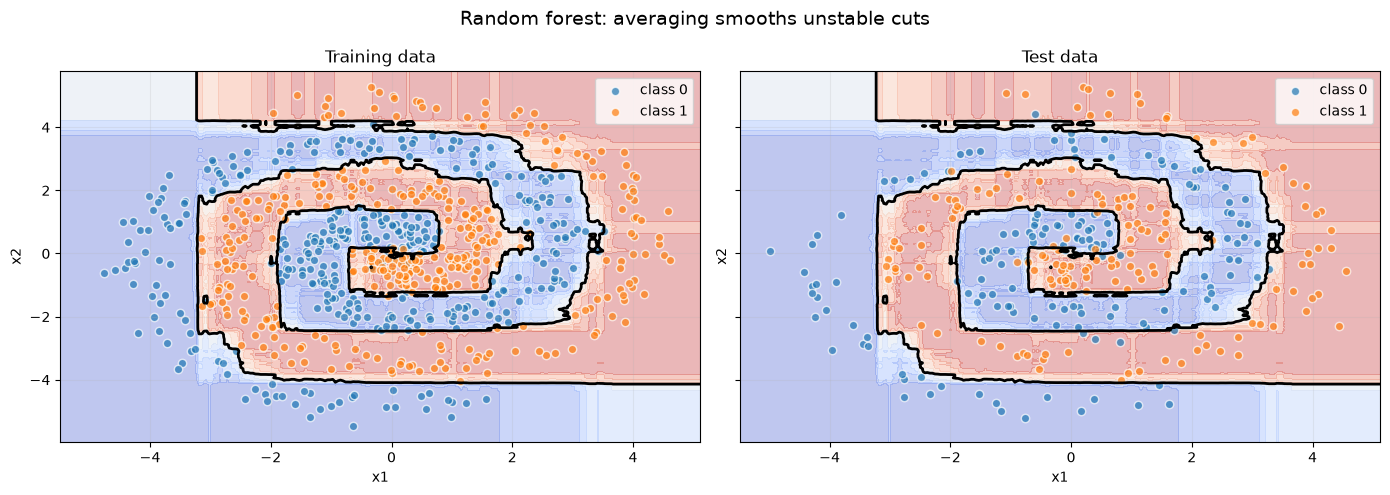

In [25]:
# Solution
spiral_forest = RandomForestClassifier(random_state=23,n_estimators=50,max_depth=18, n_jobs=-1)
spiral_forest.fit(spiral_train[FEATURES_2D], spiral_train["class"])
forest_train_predictions = spiral_forest.predict(spiral_train[FEATURES_2D])
forest_test_predictions = spiral_forest.predict(spiral_test[FEATURES_2D])
print(f"training accuracy: {accuracy_score(spiral_train['class'], forest_train_predictions):.3f}")
print(f"accuracy on unseen test data: {accuracy_score(spiral_test['class'], forest_test_predictions):.3f}")
display_classifications(spiral_forest, spiral_train, "Random forest: averaging smooths unstable cuts", test=spiral_test)

## Step 5: regression and residual correction
A piecewise-constant surface forms a face from distinct geometric regions.

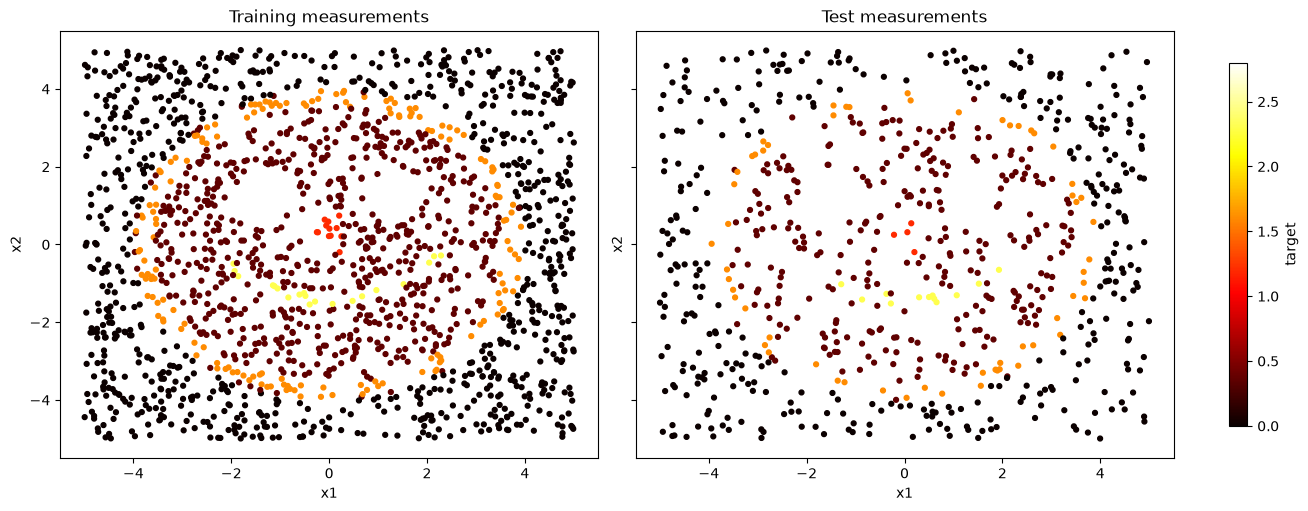

In [26]:
regression_data = pd.read_csv("data4_regression.csv")
regression_surface = pd.read_csv("data4_regression_surface.csv")
reg_train, reg_test = train_test_split(regression_data, test_size=0.3, random_state=23)
display_regression_measurements(reg_train, reg_test)

In [27]:
# Exercise: Compare regression models.

,test MAE (lower is better),test R2 (higher is better)
model,,
one tree,0.115,0.521
random forest,0.143,0.715
XGBoost,0.109,0.663
CatBoost,0.161,0.741


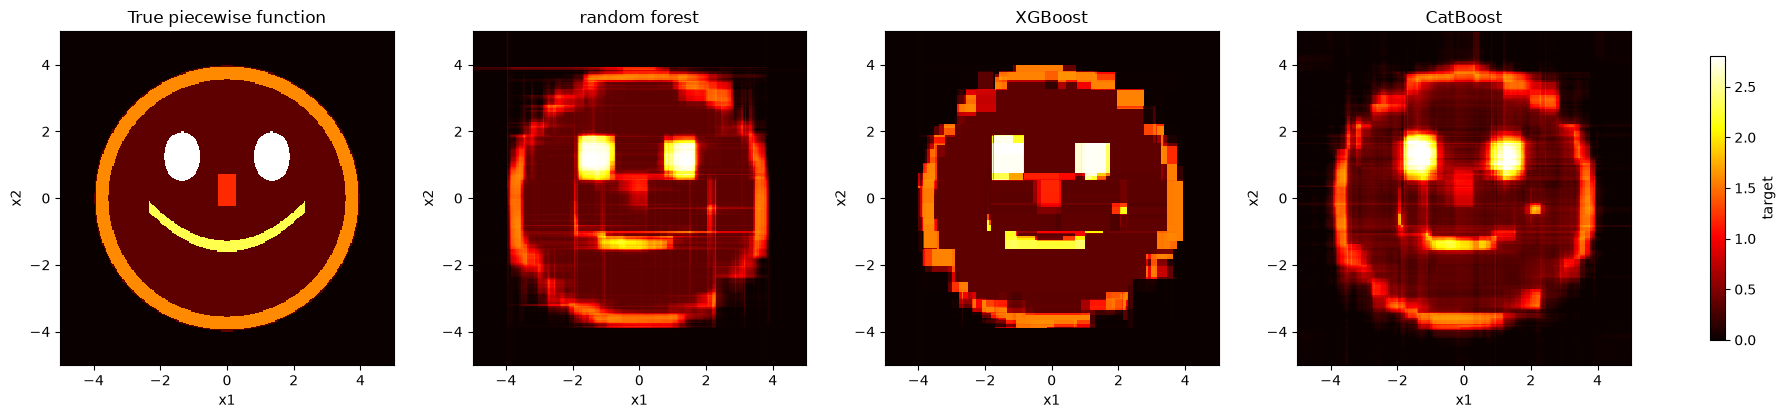

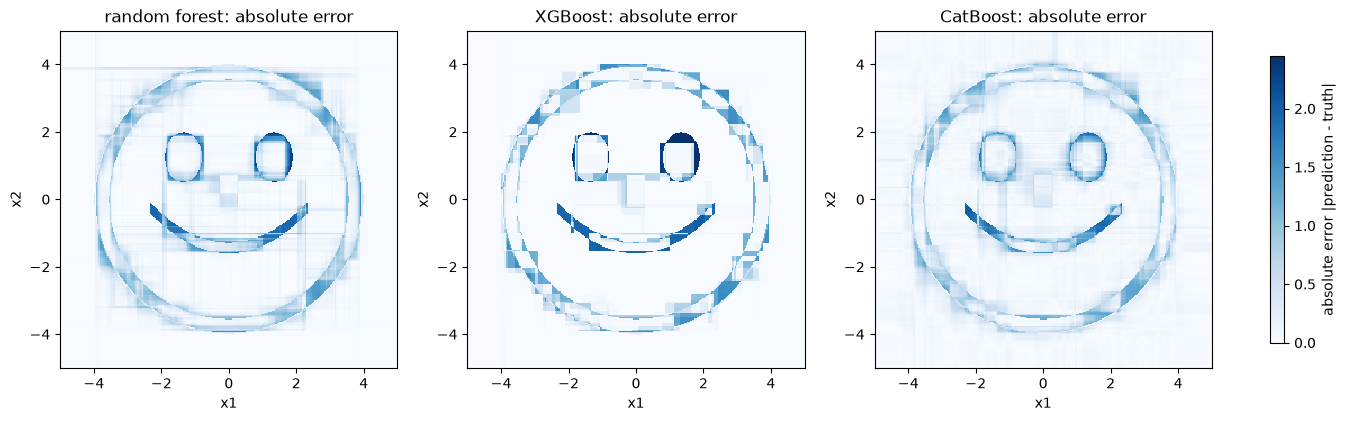

In [28]:
# Solution
regression_models = {
    "one tree": DecisionTreeRegressor(random_state=23),
    "random forest": RandomForestRegressor(random_state=23, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=23, n_jobs=-1,
                               n_estimators=100,#just guessing
                                max_depth=16,
                                learning_rate=0.04,
                           ),
    "CatBoost": CatBoostRegressor(random_seed=23,
                                  depth=10,#just guessing
                                  iterations= 500,
                                  # learning_rate=0.04,
                                  verbose=False, allow_writing_files=False),
}

rows = []
for name, model in regression_models.items():
    model.fit(reg_train[FEATURES_2D], reg_train["target"])
    rows.append({
        "model": name,
        "test MAE (lower is better)": mean_absolute_error(reg_test["target"], model.predict(reg_test[FEATURES_2D])),
        "test R2 (higher is better)": r2_score(reg_test["target"], model.predict(reg_test[FEATURES_2D])),
    })
display(pd.DataFrame(rows).set_index("model").round(3))

predicted_surfaces = {
    name: model.predict(regression_surface[FEATURES_2D])
    for name, model in regression_models.items()
    if name != "one tree"
}
display_regression_results(regression_surface, predicted_surfaces)

With sparse measurements, boosting's sequential corrections capture residual structure that the independently fitted forest trees miss.

## Independent play


In [57]:
help(XGBRegressor.__init__)
help(CatBoostRegressor.__init__)

Help on function __init__ in module xgboost.sklearn:

__init__(self, *, objective: Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'reg:squarederror', **kwargs: Any) -> None
    Initialize self.  See help(type(self)) for accurate signature.

Help on function __init__ in module catboost.core:

__init__(self, iterations=None, learning_rate=None, depth=None, l2_leaf_reg=None, model_size_reg=None, rsm=None, loss_function='RMSE', border_count=None, feature_border_type=None, per_float_feature_quantization=None, input_borders=None, output_borders=None, fold_permutation_block=None, od_pval=None, od_wait=None, od_type=None, nan_mode=None, counter_calc_method=None, leaf_estimation_iterations=None, leaf_estimation_method=None, thread_count=None, random_seed=None, use_best_model=None, best_model_min_trees=None, verbose=None, silent=None, logging_level=None, metric_period=None, ctr_leaf_count_limit=None, s

In [ ]:
CatBoostRegressor.__init__